In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [112]:
# import the data
df = pd.read_csv('placement.csv')

print(df.head())

   cgpa  placement_exam_marks  placed
0  7.19                  26.0       1
1  7.46                  38.0       1
2  7.54                  40.0       1
3  6.42                   8.0       1
4  7.23                  17.0       0


In [113]:
# Let us look at the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


- No Null values in the data

In [114]:
# Let us look at the data distribution
print(df.describe())

              cgpa  placement_exam_marks       placed
count  1000.000000           1000.000000  1000.000000
mean      6.961240             32.225000     0.489000
std       0.615898             19.130822     0.500129
min       4.890000              0.000000     0.000000
25%       6.550000             17.000000     0.000000
50%       6.960000             28.000000     0.000000
75%       7.370000             44.000000     1.000000
max       9.120000            100.000000     1.000000


- No extreme outliers can be seen in cgpa column from this data
- We can see that there might be outliers in placemen_exam_marks column
-- Reason : 75th percentile value is 44 and max value is 100 so there are last 25 percentile values from 44 to 100

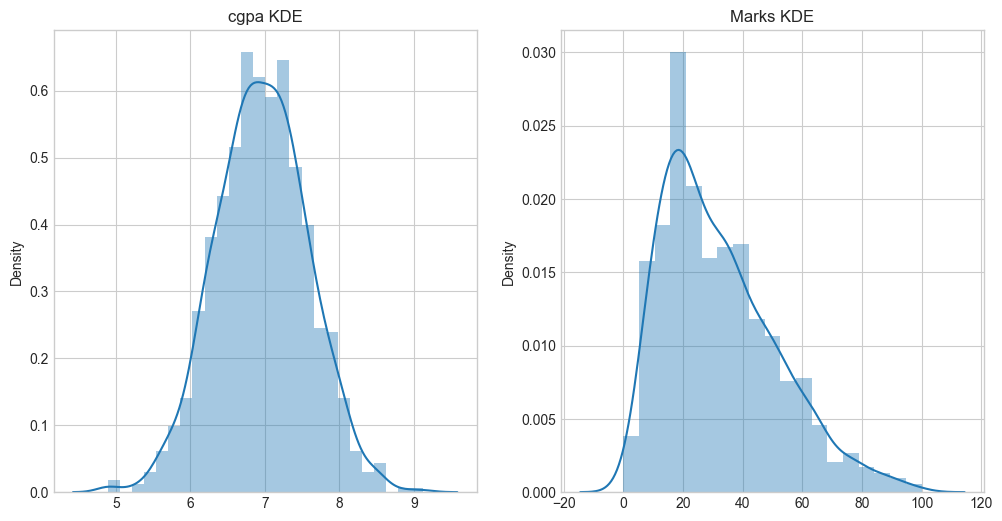

In [115]:
# Let us check the distribution of the data
fig,  ax = plt.subplots(ncols=2 , figsize=(12,6))

sns.distplot(x = df['cgpa'] , ax = ax[0])
ax[0].set_title('cgpa KDE')
sns.distplot(x = df['placement_exam_marks'] , ax=ax[1])
ax[1].set_title('Marks KDE')

plt.show()


- CGPA data is normally distributed
- Marks data is also sort of normally distributed but it is right skewed

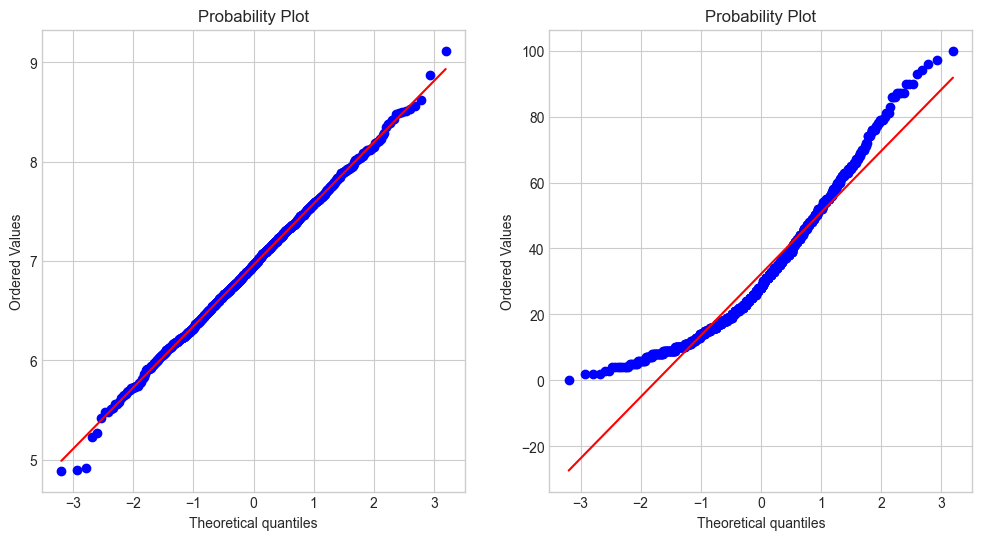

In [116]:
# Checking the QQ Plot
import scipy.stats as stats
plt.figure(figsize=(12,6))
plt.subplot(121)
stats.probplot(df['cgpa'] , plot=plt)

plt.subplot(122)
stats.probplot(df['placement_exam_marks'] , plot=plt)
plt.show()

- This confirms that cgpa is normally distributed
- Marks column is also sort of normally distributed but with skewness

In [117]:
from scipy.stats import skew, kurtosis

print(f"Skewness : {skew(df['cgpa']):.4f}")   # |value| < 0.5 → fairly symmetric
print(f"Kurtosis : {kurtosis(df['cgpa']):.4f}") # near 0 → mesokurtic (normal-like)

Skewness : -0.0145
Kurtosis : 0.0847


In [118]:
print(f"Skewness : {skew(df['placement_exam_marks']):.4f}")   # |value| < 0.5 → fairly symmetric
print(f"Kurtosis : {kurtosis(df['placement_exam_marks']):.4f}") # near 0 → mesokurtic (normal-like)

Skewness : 0.8344
Kurtosis : 0.2632


### ***Conclusion :***
- CGPA feature is normally distributed
- Sort of normal, with moderate skew
**Thus :**

- We can apply zscore tecnique only on cgpa column
- Use iqr method on Marks column to deal with the outliers


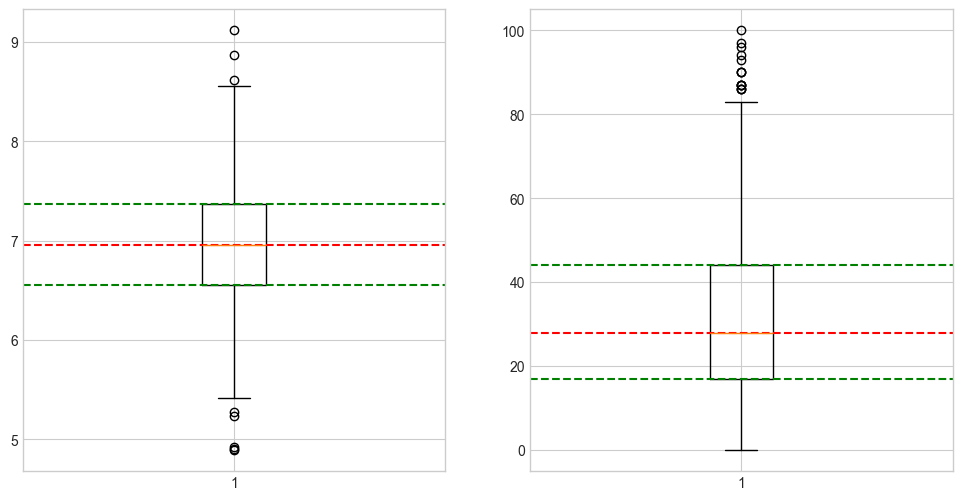

In [119]:
# Let's quickly look at the outliers

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.boxplot(df['cgpa'])
plt.axhline(np.median(df['cgpa']) , color='red' , linestyle='--')
plt.axhline(np.quantile(df['cgpa'],.25) , color='green' , linestyle='--')
plt.axhline(np.quantile(df['cgpa'],.75) , color='green' , linestyle='--')

plt.subplot(122)
plt.boxplot(df['placement_exam_marks'])
plt.axhline(np.median(df['placement_exam_marks']) , color='red' , linestyle='--')
plt.axhline(np.quantile(df['placement_exam_marks'],.25) , color='green' , linestyle='--')
plt.axhline(np.quantile(df['placement_exam_marks'],.75) , color='green' , linestyle='--')
plt.show()

- We see that CGPA has outliers on both the sides (upper end and lower end)
- Meanwhile, Marks has outliers only on the upper side

### Fitting The Original Data

In [146]:
from sklearn.preprocessing import StandardScaler

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state =42)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

model = lr.fit(X_train , y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score , root_mean_squared_error

print(f"Accuracy Score -> {accuracy_score(y_test , y_pred)}")

Accuracy Score -> 0.54


### ***Finding the interval using Z-score***

### Method 1. Scale the columns using StandardScaler and then trimming the data with [-3,3]

In [126]:
from sklearn.preprocessing import StandardScaler

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state =42)

scale = StandardScaler()
scale.set_output(transform='pandas')
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)


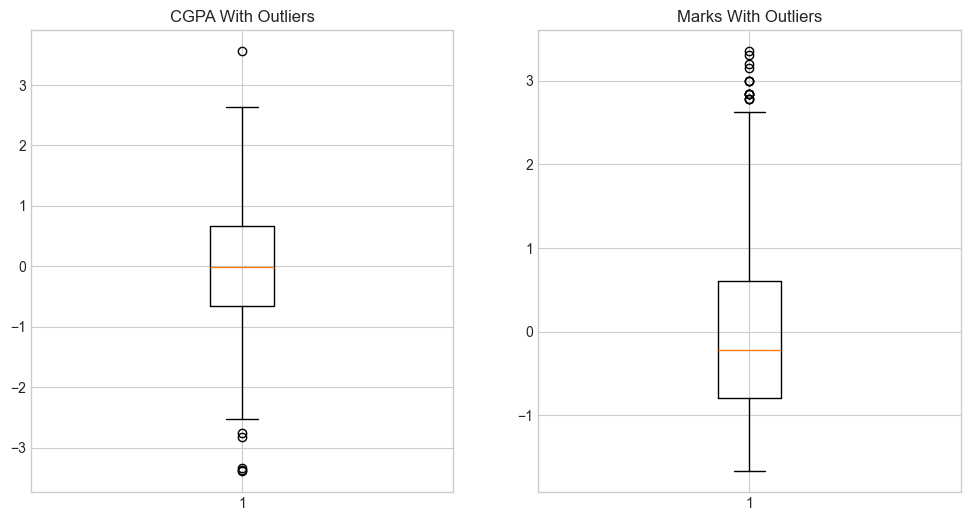

In [127]:
# Let's quickly look at the outliers

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.boxplot(X_train_scaled['cgpa'])
plt.title("CGPA With Outliers")


plt.subplot(122)
plt.boxplot(X_train_scaled['placement_exam_marks'])
plt.title("Marks With Outliers")

plt.show()

### ***Fitting the Scaled Original Data***

In [130]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

model_with_outliers = lr.fit(X_train_scaled , y_train)

y_pred_outliers = model_with_outliers.predict(X_test_scaled)

from sklearn.metrics import accuracy_score , root_mean_squared_error

print(f"Accuracy Score -> {accuracy_score(y_test , y_pred_outliers)}")

Accuracy Score -> 0.535


In [129]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test , y_pred_outliers)

array([[57, 50],
       [43, 50]])

### (i) Let us trim the data

In [131]:
print(X_train.shape)
print(X_test.shape)

(800, 2)
(200, 2)


In [132]:
X_train_scaled.describe()

,cgpa,placement_exam_marks
count,8.000000e+02,8.000000e+02
mean,1.563194e-15,-1.243450e-16
std,1.000626e+00,1.000626e+00
min,-3.387203e+00,-1.669161e+00
25%,-6.621243e-01,-7.892252e-01
50%,-5.478885e-03,-2.198547e-01
75%,6.675827e-01,6.083206e-01
max,3.556822e+00,3.351651e+00


In [133]:
condition = (X_train_scaled['cgpa'] >= -3) & (X_train_scaled['cgpa'] <= 3)

# This will now show ALL outliers (both sides)
outliers = X_train_scaled[~condition]

outliers_index = outliers.index.to_list() # This is because we need to remove them from Target variable also
print(outliers)

         cgpa  placement_exam_marks
485 -3.337954              0.608321
997 -3.387203              0.090711
999 -3.370787             -1.151552
996  3.556822              1.695301


- We will remove these indexes

In [134]:
outliers.index.to_list()

[485, 997, 999, 996]

In [135]:
X_train_new = X_train_scaled[condition]
X_test_scaled['cgpa'] = X_test_scaled['cgpa'].clip(-3,3)
X_test_new = X_test_scaled
y_train_new = y_train.drop(outliers_index)

### Let us work on Fare Column

- Here we will use IQR Method To remove the outliers

In [136]:
q3 = np.quantile(X_train_new['placement_exam_marks'],.75)
q1 = np.quantile(X_train_new['placement_exam_marks'],.25)

IQR = q3-q1


lower = 0 - 1.5*IQR
upper = 0 + 1.5*IQR

print([lower,"-",upper])


[np.float64(-2.0963186608333224), '-', np.float64(2.0963186608333224)]


In [137]:
X_train_outliers_removed = X_train_new[((X_train_new['placement_exam_marks'] >= lower)& (X_train_new['placement_exam_marks'] <= upper))]

outliers_removed = X_train_new[~((X_train_new['placement_exam_marks'] >= lower)& (X_train_new['placement_exam_marks'] <= upper))].index.to_list()

In [138]:
X_train_outliers_removed

,cgpa,placement_exam_marks
29,-0.727789,-0.892747
535,-0.760621,1.540018
695,-0.333802,-1.099791
557,-0.793453,-0.375138
836,0.224347,0.038950
...,...,...
106,-0.596460,-0.530420
270,-0.251721,-0.840986
860,0.913825,-0.582181
435,0.815328,0.245994


In [139]:
y_train_outliers_removed = y_train_new.drop(outliers_removed)

In [140]:
print(X_train_outliers_removed.shape)
print(y_train_outliers_removed.shape)

(762, 2)
(762,)


In [141]:
X_test_new['placement_exam_marks'] = X_test_new['placement_exam_marks'].clip(lower , upper)
X_test_outliers_capped = X_test_new

In [142]:
print(X_test_outliers_capped.describe())

             cgpa  placement_exam_marks
count  200.000000            200.000000
mean     0.064132             -0.016437
std      1.050672              0.919958
min     -2.287322             -1.462118
25%     -0.567732             -0.750404
50%      0.084810             -0.219855
75%      0.745559              0.673022
max      3.000000              2.096319


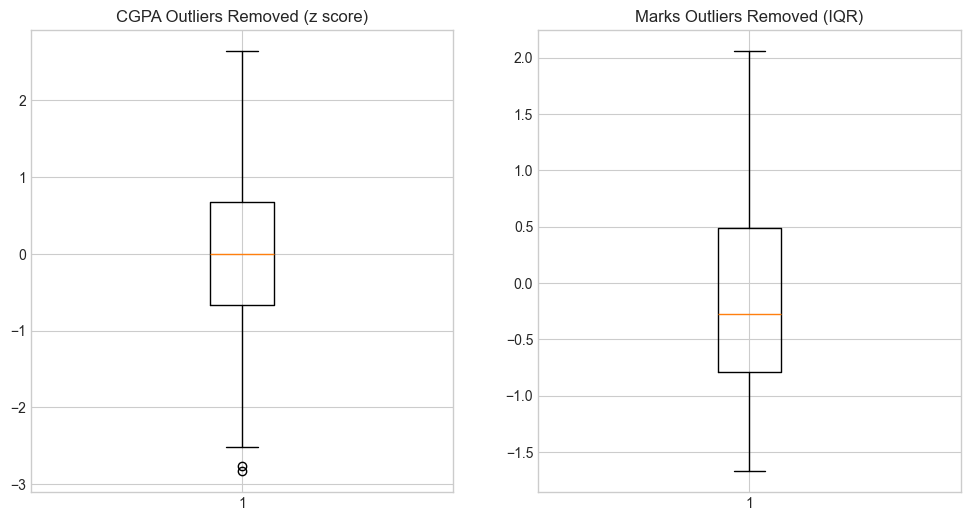

In [143]:
# Let's quickly look at the outliers

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.boxplot(X_train_outliers_removed['cgpa'])
plt.title('CGPA Outliers Removed (z score)')

plt.subplot(122)
plt.boxplot(X_train_outliers_removed['placement_exam_marks'])
plt.title('Marks Outliers Removed (IQR)')

plt.show()

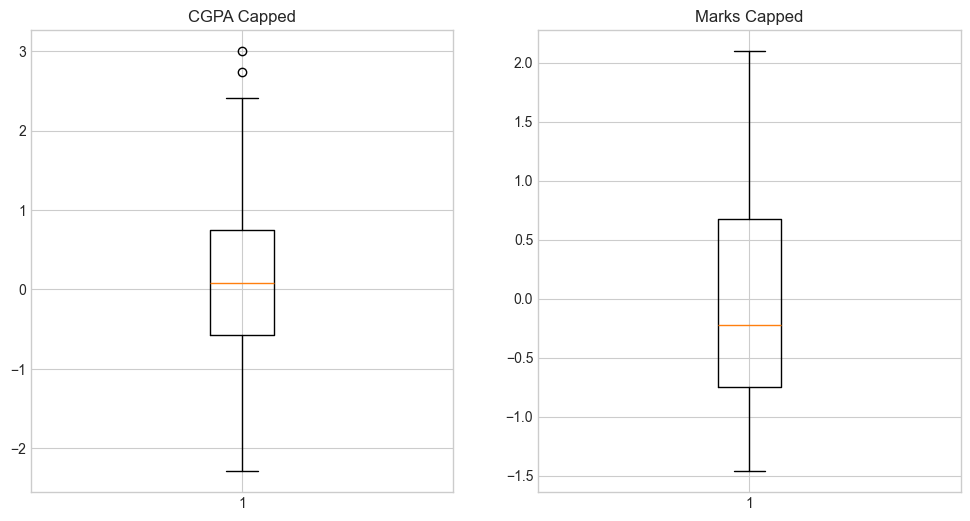

In [144]:
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.boxplot(X_test_outliers_capped['cgpa'])
plt.title('CGPA Capped')

plt.subplot(122)
plt.boxplot(X_test_outliers_capped['placement_exam_marks'])
plt.title('Marks Capped')

plt.show()

### Let ud fit the Trimmed and Scaled data

In [145]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

model_with_outliers = lr.fit(X_train_outliers_removed , y_train_outliers_removed)

y_pred_outliers_removed = model_with_outliers.predict(X_test_outliers_capped)

from sklearn.metrics import accuracy_score , root_mean_squared_error

print(f"Accuracy Score -> {accuracy_score(y_test , y_pred_outliers_removed)}")

Accuracy Score -> 0.54
